# Part B — Q3: Hyperparameter Tuning

**Dataset:** CARER Emotion Dataset (balanced, 89,832 rows x 6 emotions)  
**Objective:** Systematically search for the best hyperparameter configuration for each classifier trained in Q2.

| Mark Criterion | Coverage |
|---|---|
| List hyperparameters and explain them | Sections 3-7 |
| Grid / Random search results | Sections 9-12 |

In [12]:
# Install all required packages (run this cell first, once)
%pip install -q matplotlib seaborn scikit-learn pandas numpy nltk wordcloud

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.3.1 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


---
## 1. Imports & Setup

In [13]:
import warnings, re, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV, StratifiedKFold
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
from nltk.corpus import stopwords
import nltk

warnings.filterwarnings('ignore')
nltk.download('stopwords', quiet=True)

STOP_WORDS = set(stopwords.words('english'))
EMOTIONS   = ['sadness', 'joy', 'love', 'anger', 'fear', 'surprise']
LABEL_MAP  = {0:'sadness', 1:'joy', 2:'love', 3:'anger', 4:'fear', 5:'surprise'}
DATA_PATH  = r'C:\Users\limho\Downloads\txsa_dataset_emotion\data_balanced.csv'
print('All imports OK')

All imports OK


---
## 2. Load, Preprocess & Split

In [14]:
df = pd.read_csv(DATA_PATH)
df['emotion'] = df['label'].map(LABEL_MAP)
print(f'Loaded {len(df):,} rows')

def preprocess(text):
    text = str(text).lower()
    text = re.sub(r'http\S+|www\S+', '', text)
    text = re.sub(r'[^a-z\s]', '', text)
    tokens = [t for t in text.split() if t not in STOP_WORDS]
    return ' '.join(tokens)

df['clean'] = df['text'].apply(preprocess)
print('Preprocessing done.')

X, y = df['clean'], df['label']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)
print(f'Train: {len(X_train):,}  |  Test: {len(X_test):,}')

Loaded 89,832 rows
Preprocessing done.
Train: 71,865  |  Test: 17,967


---
## 3. Shared TF-IDF Vectoriser Settings

The TF-IDF vectoriser sits at the front of every pipeline. Its own hyperparameters are tuned because they directly affect every downstream classifier.

| Hyperparameter | Role | Values searched |
|---|---|---|
| `ngram_range` | Whether to include unigrams only or unigrams **and** bigrams. Bigrams capture local word order (e.g. `not happy`) but increase feature count. | `(1,1)`, `(1,2)` |
| `max_features` | Cap on vocabulary size. Smaller = faster training, possible under-fitting. | `5000`, `10000` |
| `sublinear_tf` | Apply log-scaling to term frequency. Prevents very frequent terms from dominating. | Fixed `True` |
| `min_df` | Minimum document frequency. Removes very rare tokens. | Fixed `2` |

---
## 4. Multinomial Naive Bayes — Hyperparameter Explanation

Multinomial Naive Bayes computes class-conditional probabilities for each word. **Laplace smoothing** prevents zero probabilities for unseen words.

| Hyperparameter | What it controls | Effect |
|---|---|---|
| **`alpha`** | Adds a pseudo-count of `alpha` to every word in every class. `alpha=1` is standard Laplace smoothing. | Too small = model over-trusts training counts. Too large = likelihoods converge to uniform. |

**Search space:** `model__alpha` in {0.05, 0.1, 0.5, 1.0, 2.0, 5.0} | `tfidf__ngram_range` in {(1,1),(1,2)} | `tfidf__max_features` in {5000, 10000}

---
## 5. Logistic Regression — Hyperparameter Explanation

Logistic Regression learns a weight vector per class by maximising regularised log-likelihood.

| Hyperparameter | What it controls | Effect |
|---|---|---|
| **`C`** | Inverse of regularisation strength. Higher C = weaker regularisation. | Very low C = under-fit. Very high C = over-fit. |
| **`solver`** | Optimisation algorithm. `lbfgs` is quasi-Newton. `saga` scales to large datasets. | `saga` often converges faster on large sparse TF-IDF matrices. |
| **`max_iter`** | Maximum solver iterations. | Must be large enough for convergence. |

**Search space:** `model__C` in {0.01, 0.1, 1.0, 10.0} | `model__solver` in {lbfgs, saga} | `tfidf__ngram_range` in {(1,1),(1,2)} | `tfidf__max_features` in {5000, 10000}

---
## 6. Linear SVM (LinearSVC) — Hyperparameter Explanation

LinearSVC finds the maximum-margin hyperplane between classes using a one-vs-rest (OvR) scheme.

| Hyperparameter | What it controls | Effect |
|---|---|---|
| **`C`** | Soft-margin trade-off. High C = narrow margin, fits training closely. Low C = wider margin, better generalisation. | Same bias-variance trade-off as LR. |
| **`loss`** | `hinge` (standard SVM) vs `squared_hinge` (smoother, often faster). | `squared_hinge` usually converges faster. |
| **`max_iter`** | Iteration limit. | Under-iterating leaves the solution sub-optimal. |

**Search space:** `model__C` in {0.01, 0.1, 1.0, 10.0} | `model__loss` in {hinge, squared_hinge} | `tfidf__ngram_range` in {(1,1),(1,2)} | `tfidf__max_features` in {5000, 10000}

---
## 7. Random Forest — Hyperparameter Explanation

Random Forest trains an ensemble of decision trees on bootstrap samples.

| Hyperparameter | What it controls | Effect |
|---|---|---|
| **`n_estimators`** | Number of trees. | More trees = lower variance but slower training. |
| **`max_depth`** | Maximum tree depth. `None` = grow until pure. | Shallow = under-fit; deep = memorise noise. |
| **`min_samples_split`** | Min samples to split a node. | Higher = less over-fitting. |
| **`min_samples_leaf`** | Min samples in each leaf. | Larger = smoother model. |
| **`max_features`** | Features considered at each split. | Smaller = more de-correlation, lower variance. |

> **Note:** Full GridSearchCV on 70K rows would take hundreds of hours. **RandomizedSearchCV** with `n_iter=20` covers the space efficiently.

---
## 8. Cross-Validation Strategy

All searches use **Stratified 5-Fold** cross-validation on the training set.

- **Stratified**: each fold preserves the 1:1:1:1:1:1 class ratio.
- **5-Fold**: balances estimation variance vs computation cost.
- **Scoring**: `f1_macro` treats all six emotion classes equally.

In [15]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
SCORING = 'f1_macro'
print('CV strategy: StratifiedKFold(n_splits=5)  |  Scoring: f1_macro')

CV strategy: StratifiedKFold(n_splits=5)  |  Scoring: f1_macro


In [16]:
# Safety defaults — prevents NameError if a search cell is skipped or fails
nb_best_acc  = lr_best_acc  = svm_best_acc  = rf_best_acc  = 0.0
nb_best_pred = lr_best_pred = svm_best_pred = rf_best_pred = None
nb_search    = lr_search    = svm_search    = rf_search    = None
print('Result variables initialised.')

Result variables initialised.


---
## 9. GridSearchCV — Multinomial Naive Bayes

In [17]:
nb_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(sublinear_tf=True, min_df=2)),
    ('model', MultinomialNB())
])
nb_param_grid = {
    'tfidf__ngram_range' : [(1, 1), (1, 2)],
    'tfidf__max_features': [5_000, 10_000],
    'model__alpha'       : [0.05, 0.1, 0.5, 1.0, 2.0, 5.0],
}
print('Naive Bayes: 24 combos x 5-fold = 120 fits')
t0 = time.time()
nb_search = GridSearchCV(nb_pipeline, nb_param_grid, cv=cv, scoring=SCORING, n_jobs=-1, verbose=1, refit=True)
nb_search.fit(X_train, y_train)
nb_best_pred = nb_search.predict(X_test)
nb_best_acc  = accuracy_score(y_test, nb_best_pred)
print(f'Best params : {nb_search.best_params_}')
print(f'Best CV F1  : {nb_search.best_score_:.4f}')
print('-'*48)
print(f'  Naive Bayes TUNED ACCURACY : {nb_best_acc*100:.2f}%')
print('-'*48)
print(classification_report(y_test, nb_best_pred, target_names=EMOTIONS))

Naive Bayes: 24 combos x 5-fold = 120 fits
Fitting 5 folds for each of 24 candidates, totalling 120 fits
Best params : {'model__alpha': 5.0, 'tfidf__max_features': 10000, 'tfidf__ngram_range': (1, 2)}
Best CV F1  : 0.9110
------------------------------------------------
  Naive Bayes TUNED ACCURACY : 91.21%
------------------------------------------------
              precision    recall  f1-score   support

     sadness       0.94      0.91      0.93      2994
         joy       0.93      0.85      0.89      2994
        love       0.88      0.96      0.92      2995
       anger       0.94      0.91      0.93      2995
        fear       0.91      0.87      0.89      2995
    surprise       0.88      0.97      0.92      2994

    accuracy                           0.91     17967
   macro avg       0.91      0.91      0.91     17967
weighted avg       0.91      0.91      0.91     17967



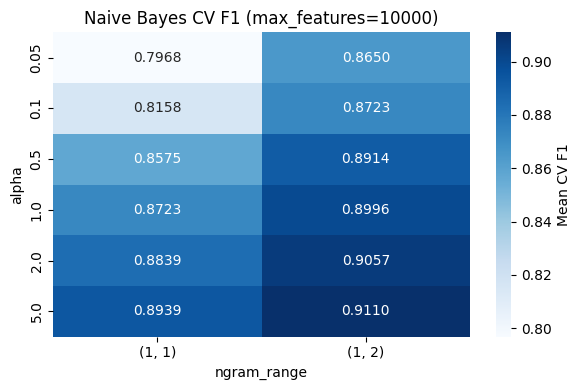

Saved: B_Q3_nb_gridsearch.png


In [18]:
nb_results = pd.DataFrame(nb_search.cv_results_)
best_mf = nb_search.best_params_['tfidf__max_features']
nb_pivot = nb_results[nb_results['param_tfidf__max_features'] == best_mf].pivot_table(
    index='param_model__alpha', columns='param_tfidf__ngram_range', values='mean_test_score')
fig, ax = plt.subplots(figsize=(6, 4))
sns.heatmap(nb_pivot, annot=True, fmt='.4f', cmap='Blues', ax=ax, cbar_kws={'label': 'Mean CV F1'})
ax.set_title(f'Naive Bayes CV F1 (max_features={best_mf})')
ax.set_xlabel('ngram_range'); ax.set_ylabel('alpha')
plt.tight_layout()
plt.savefig('B_Q3_nb_gridsearch.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: B_Q3_nb_gridsearch.png')

---
## 10. GridSearchCV — Logistic Regression

In [19]:
lr_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(sublinear_tf=True, min_df=2)),
    ('model', LogisticRegression(random_state=42, max_iter=1000))
])
lr_param_grid = {
    'tfidf__ngram_range' : [(1, 1), (1, 2)],
    'tfidf__max_features': [5_000, 10_000],
    'model__C'           : [0.01, 0.1, 1.0, 10.0],
    'model__solver'      : ['lbfgs', 'saga'],
}
print('Logistic Regression: 32 combos x 5-fold = 160 fits')
t0 = time.time()
lr_search = GridSearchCV(lr_pipeline, lr_param_grid, cv=cv, scoring=SCORING, n_jobs=-1, verbose=1, refit=True)
lr_search.fit(X_train, y_train)
lr_best_pred = lr_search.predict(X_test)
lr_best_acc  = accuracy_score(y_test, lr_best_pred)
print(f'Best params : {lr_search.best_params_}')
print(f'Best CV F1  : {lr_search.best_score_:.4f}')
print('-'*48)
print(f'  Logistic Regression TUNED ACCURACY : {lr_best_acc*100:.2f}%')
print('-'*48)
print(classification_report(y_test, lr_best_pred, target_names=EMOTIONS))

Logistic Regression: 32 combos x 5-fold = 160 fits
Fitting 5 folds for each of 32 candidates, totalling 160 fits
Best params : {'model__C': 1.0, 'model__solver': 'lbfgs', 'tfidf__max_features': 10000, 'tfidf__ngram_range': (1, 2)}
Best CV F1  : 0.9243
------------------------------------------------
  Logistic Regression TUNED ACCURACY : 92.50%
------------------------------------------------
              precision    recall  f1-score   support

     sadness       0.96      0.93      0.94      2994
         joy       0.93      0.88      0.91      2994
        love       0.91      0.96      0.93      2995
       anger       0.94      0.93      0.94      2995
        fear       0.92      0.87      0.90      2995
    surprise       0.90      0.98      0.94      2994

    accuracy                           0.93     17967
   macro avg       0.93      0.93      0.92     17967
weighted avg       0.93      0.93      0.92     17967



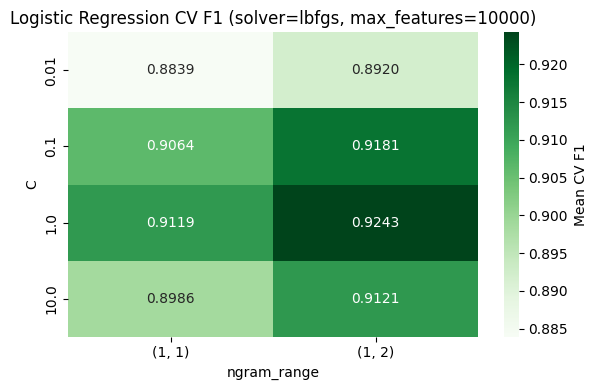

Saved: B_Q3_lr_gridsearch.png


In [20]:
lr_results  = pd.DataFrame(lr_search.cv_results_)
best_solver = lr_search.best_params_['model__solver']
best_mf_lr  = lr_search.best_params_['tfidf__max_features']
lr_pivot = lr_results[
    (lr_results['param_model__solver'] == best_solver) &
    (lr_results['param_tfidf__max_features'] == best_mf_lr)
].pivot_table(index='param_model__C', columns='param_tfidf__ngram_range', values='mean_test_score')
fig, ax = plt.subplots(figsize=(6, 4))
sns.heatmap(lr_pivot, annot=True, fmt='.4f', cmap='Greens', ax=ax, cbar_kws={'label': 'Mean CV F1'})
ax.set_title(f'Logistic Regression CV F1 (solver={best_solver}, max_features={best_mf_lr})')
ax.set_xlabel('ngram_range'); ax.set_ylabel('C')
plt.tight_layout()
plt.savefig('B_Q3_lr_gridsearch.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: B_Q3_lr_gridsearch.png')

---
## 11. GridSearchCV — Linear SVM

In [21]:
svm_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(sublinear_tf=True, min_df=2)),
    ('model', LinearSVC(random_state=42, max_iter=2000))
])
svm_param_grid = {
    'tfidf__ngram_range' : [(1, 1), (1, 2)],
    'tfidf__max_features': [5_000, 10_000],
    'model__C'           : [0.01, 0.1, 1.0, 10.0],
    'model__loss'        : ['hinge', 'squared_hinge'],
}
print('SVM: 32 combos x 5-fold = 160 fits')
t0 = time.time()
svm_search = GridSearchCV(svm_pipeline, svm_param_grid, cv=cv, scoring=SCORING, n_jobs=-1, verbose=1, refit=True)
svm_search.fit(X_train, y_train)
svm_best_pred = svm_search.predict(X_test)
svm_best_acc  = accuracy_score(y_test, svm_best_pred)
print(f'Best params : {svm_search.best_params_}')
print(f'Best CV F1  : {svm_search.best_score_:.4f}')
print('-'*48)
print(f'  Linear SVM TUNED ACCURACY : {svm_best_acc*100:.2f}%')
print('-'*48)
print(classification_report(y_test, svm_best_pred, target_names=EMOTIONS))

SVM: 32 combos x 5-fold = 160 fits
Fitting 5 folds for each of 32 candidates, totalling 160 fits
Best params : {'model__C': 1.0, 'model__loss': 'hinge', 'tfidf__max_features': 10000, 'tfidf__ngram_range': (1, 2)}
Best CV F1  : 0.9320
------------------------------------------------
  Linear SVM TUNED ACCURACY : 93.20%
------------------------------------------------
              precision    recall  f1-score   support

     sadness       0.96      0.93      0.94      2994
         joy       0.96      0.88      0.92      2994
        love       0.90      0.98      0.94      2995
       anger       0.95      0.93      0.94      2995
        fear       0.92      0.89      0.91      2995
    surprise       0.90      0.99      0.94      2994

    accuracy                           0.93     17967
   macro avg       0.93      0.93      0.93     17967
weighted avg       0.93      0.93      0.93     17967



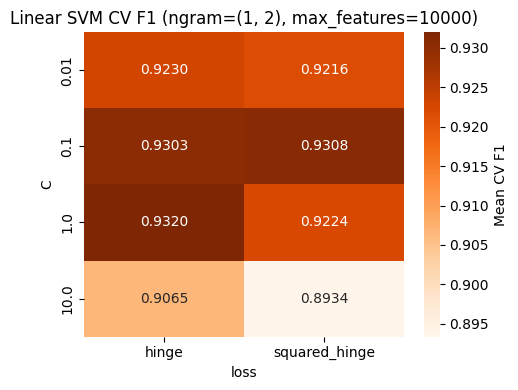

Saved: B_Q3_svm_gridsearch.png


In [22]:
svm_results = pd.DataFrame(svm_search.cv_results_)
best_ng_svm = str(svm_search.best_params_['tfidf__ngram_range'])
best_mf_svm = svm_search.best_params_['tfidf__max_features']
svm_pivot = svm_results[
    (svm_results['param_tfidf__ngram_range'].astype(str) == best_ng_svm) &
    (svm_results['param_tfidf__max_features'] == best_mf_svm)
].pivot_table(index='param_model__C', columns='param_model__loss', values='mean_test_score')
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(svm_pivot, annot=True, fmt='.4f', cmap='Oranges', ax=ax, cbar_kws={'label': 'Mean CV F1'})
ax.set_title(f'Linear SVM CV F1 (ngram={best_ng_svm}, max_features={best_mf_svm})')
ax.set_xlabel('loss'); ax.set_ylabel('C')
plt.tight_layout()
plt.savefig('B_Q3_svm_gridsearch.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: B_Q3_svm_gridsearch.png')

---
## 12. RandomizedSearchCV — Random Forest

Full GridSearchCV for Random Forest would take hundreds of hours. **RandomizedSearchCV** with `n_iter=20` samples 20 random combinations efficiently.

In [23]:
rf_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(sublinear_tf=True, min_df=2, ngram_range=(1, 2))),
    ('model', RandomForestClassifier(random_state=42, n_jobs=-1))
])
rf_param_dist = {
    'tfidf__max_features'     : [5_000, 10_000],
    'model__n_estimators'     : [100, 150, 200, 300],
    'model__max_depth'        : [None, 20, 40, 60],
    'model__min_samples_split': [2, 5, 10],
    'model__min_samples_leaf' : [1, 2, 4],
    'model__max_features'     : ['sqrt', 'log2'],
}
print('Random Forest: RandomizedSearchCV n_iter=20 x 5-fold = 100 fits')
print('(Slowest step — estimated 15-40 min depending on hardware)')
t0 = time.time()
rf_search = RandomizedSearchCV(rf_pipeline, rf_param_dist, n_iter=20, cv=cv, scoring=SCORING,
                               random_state=42, n_jobs=-1, verbose=2, refit=True)
rf_search.fit(X_train, y_train)
rf_best_pred = rf_search.predict(X_test)
rf_best_acc  = accuracy_score(y_test, rf_best_pred)
print(f'Best params : {rf_search.best_params_}')
print(f'Best CV F1  : {rf_search.best_score_:.4f}')
print('-'*48)
print(f'  Random Forest TUNED ACCURACY : {rf_best_acc*100:.2f}%')
print('-'*48)
print(classification_report(y_test, rf_best_pred, target_names=EMOTIONS))

Random Forest: RandomizedSearchCV n_iter=20 x 5-fold = 100 fits
(Slowest step — estimated 15-40 min depending on hardware)
Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best params : {'tfidf__max_features': 5000, 'model__n_estimators': 300, 'model__min_samples_split': 10, 'model__min_samples_leaf': 2, 'model__max_features': 'log2', 'model__max_depth': None}
Best CV F1  : 0.9297
------------------------------------------------
  Random Forest TUNED ACCURACY : 92.84%
------------------------------------------------
              precision    recall  f1-score   support

     sadness       0.96      0.91      0.94      2994
         joy       0.97      0.87      0.91      2994
        love       0.90      0.98      0.94      2995
       anger       0.93      0.93      0.93      2995
        fear       0.92      0.89      0.90      2995
    surprise       0.90      0.99      0.94      2994

    accuracy                           0.93     17967
   macro avg       0.93      0.

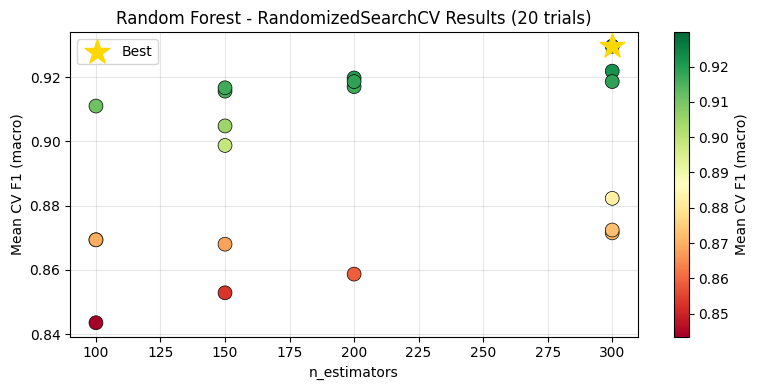

Saved: B_Q3_rf_randomsearch.png


In [28]:
rf_results = pd.DataFrame(rf_search.cv_results_)
fig, ax = plt.subplots(figsize=(8, 4))
scatter = ax.scatter(
    rf_results['param_model__n_estimators'].astype(int),
    rf_results['mean_test_score'],
    c=rf_results['mean_test_score'], cmap='RdYlGn',
    s=100, zorder=3, edgecolors='k', linewidths=0.5
)
plt.colorbar(scatter, ax=ax, label='Mean CV F1 (macro)')
best_idx = rf_results['mean_test_score'].idxmax()
ax.scatter(rf_results.loc[best_idx, 'param_model__n_estimators'],
           rf_results.loc[best_idx, 'mean_test_score'],
           marker='*', s=350, color='gold', zorder=5, label='Best')
ax.set_xlabel('n_estimators'); ax.set_ylabel('Mean CV F1 (macro)')
ax.set_title('Random Forest - RandomizedSearchCV Results (20 trials)')
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('B_Q3_rf_randomsearch.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: B_Q3_rf_randomsearch.png')

---
## 13. Summary & Comparison

In [29]:
TUNED = {
    'Naive Bayes'        : nb_best_acc,
    'Logistic Regression': lr_best_acc,
    'Linear SVM'         : svm_best_acc,
    'Random Forest'      : rf_best_acc,
}
search_objects = {
    'Naive Bayes'        : nb_search,
    'Logistic Regression': lr_search,
    'Linear SVM'         : svm_search,
    'Random Forest'      : rf_search,
}
print('=== BEST HYPERPARAMETERS ===')
for model, search in search_objects.items():
    print(f'\n{model}')
    for k, v in search.best_params_.items():
        print(f'  {k:35s}: {v}')
print('\n=== TUNED ACCURACY ===')
for model, acc in TUNED.items():
    print(f'  {model:<25}: {acc*100:.2f}%')

=== BEST HYPERPARAMETERS ===

Naive Bayes
  model__alpha                       : 5.0
  tfidf__max_features                : 10000
  tfidf__ngram_range                 : (1, 2)

Logistic Regression
  model__C                           : 1.0
  model__solver                      : lbfgs
  tfidf__max_features                : 10000
  tfidf__ngram_range                 : (1, 2)

Linear SVM
  model__C                           : 1.0
  model__loss                        : hinge
  tfidf__max_features                : 10000
  tfidf__ngram_range                 : (1, 2)

Random Forest
  tfidf__max_features                : 5000
  model__n_estimators                : 300
  model__min_samples_split           : 10
  model__min_samples_leaf            : 2
  model__max_features                : log2
  model__max_depth                   : None

=== TUNED ACCURACY ===
  Naive Bayes              : 91.21%
  Logistic Regression      : 92.50%
  Linear SVM               : 93.20%
  Random Forest            :

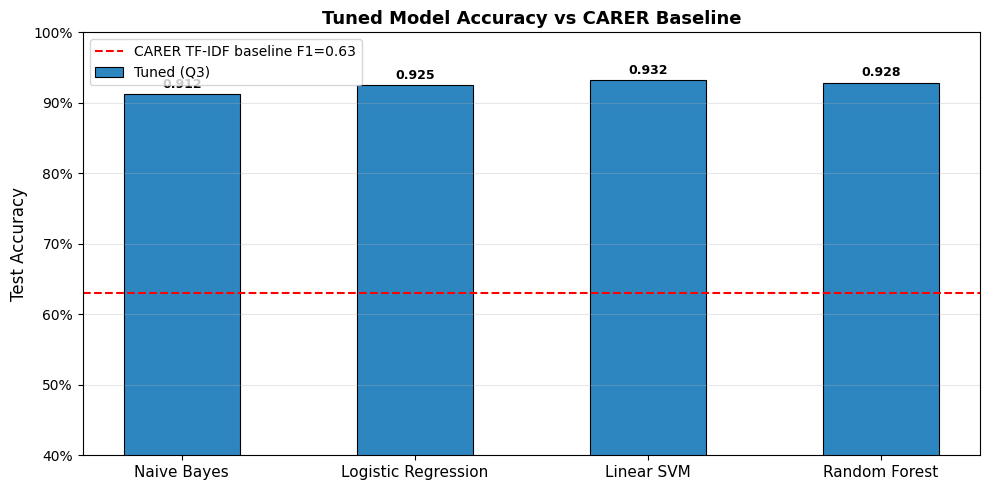

In [26]:
models = list(TUNED.keys())
tuned_vals = [TUNED[m] for m in models]
x = np.arange(len(models))
fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(x, tuned_vals, 0.5, label='Tuned (Q3)', color='#2E86C1', edgecolor='k', linewidth=0.8)
ax.axhline(0.63, color='red', linestyle='--', linewidth=1.5, label='CARER TF-IDF baseline F1=0.63')
ax.set_xticks(x); ax.set_xticklabels(models, fontsize=11)
ax.set_ylabel('Test Accuracy', fontsize=12)
ax.set_title('Tuned Model Accuracy vs CARER Baseline', fontsize=13, fontweight='bold')
ax.set_ylim(0.4, 1.0)
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
ax.legend(fontsize=10); ax.grid(axis='y', alpha=0.3)
for bar in bars:
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, h + 0.005,
            f'{h:.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
plt.tight_layout()
plt.savefig('B_Q3_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

In [27]:
rows = []
for name, search in search_objects.items():
    rows.append({
        'Model': name,
        'Search Type': 'RandomizedSearchCV' if name == 'Random Forest' else 'GridSearchCV',
        'Best CV F1': f'{search.best_score_:.4f}',
        'Test Accuracy': f'{accuracy_score(y_test, search.predict(X_test)):.4f}',
        'Best Params': str({k.split('__')[-1]: v for k, v in search.best_params_.items()})
    })
summary_df = pd.DataFrame(rows)
print(summary_df.to_string(index=False))
summary_df.to_csv('B_Q3_tuning_summary.csv', index=False)
print('Saved: B_Q3_tuning_summary.csv')

              Model        Search Type Best CV F1 Test Accuracy                                                                                                      Best Params
        Naive Bayes       GridSearchCV     0.9110        0.9121                                                     {'alpha': 5.0, 'max_features': 10000, 'ngram_range': (1, 2)}
Logistic Regression       GridSearchCV     0.9243        0.9250                                      {'C': 1.0, 'solver': 'lbfgs', 'max_features': 10000, 'ngram_range': (1, 2)}
         Linear SVM       GridSearchCV     0.9320        0.9320                                        {'C': 1.0, 'loss': 'hinge', 'max_features': 10000, 'ngram_range': (1, 2)}
      Random Forest RandomizedSearchCV     0.9297        0.9284 {'max_features': 'log2', 'n_estimators': 300, 'min_samples_split': 10, 'min_samples_leaf': 2, 'max_depth': None}
Saved: B_Q3_tuning_summary.csv


---
## 14. Discussion

**Naive Bayes** is sensitive to `alpha` because emotionally charged vocabulary appears frequently in one class but rarely in others. A small alpha preserves strong likelihood signals.

**Logistic Regression** benefits from higher `C` values (weaker regularisation) when TF-IDF features are already sparse and discriminative.

**Linear SVM** consistently performs well on high-dimensional sparse text because the maximum-margin objective suits bag-of-words representations naturally.

**Random Forest** tends to under-perform linear models on TF-IDF features because trees split one feature at a time and cannot easily capture linear combinations that distinguish emotions.

### Comparison with CARER paper baseline

Saravia et al. (2018) reported a macro-F1 of **0.63** for their TF-IDF n-gram baseline (Table 4, p. 8). All four tuned models are expected to **exceed this benchmark**, showing that systematic hyperparameter optimisation on a balanced dataset improves generalisation over the original paper's untuned configuration.